importing libs and loading the data

In [ ]:
#IMport all the necessary lib stuff
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [46]:
# read the csv
data = pd.read_csv("train.csv")

In [ ]:
# nconverting to numpy array
data = np.array(data)
m, n = data.shape 
# shuffle before splitting so train/dev arent biased by row order 
np.random.shuffle(data)

# dev split

In [48]:
data_dev = data[0:1000]
Y_dev = data_dev[:, 0].astype(int)
X_dev = data_dev[:, 1:n]
X_dev = X_dev.T / 255

# train split

In [49]:
data_train = data[1000:m]
Y_train = data_train[:, 0].astype(int)
X_train = data_train[:, 1:n]
X_train = X_train.T / 255
_, m_train = X_train.shape

In [50]:
def init_params():
  const = 0.5  # random weights, shifted so they range from -0.5 to 0.5 instead of 0 to 1
  W1 = np.random.rand(10, 784) - const
  b1 = np.random.rand(10,1) - const
  W2 = np.random.rand(10,10) - const
  b2 = np.random.rand(10,1) - const
  return W1, b1, W2, b2

In [51]:
def Relu(Z):
  return np.maximum(Z, 0)

def Softmax(Z):
    # Z is (10, m), 10 classes as rows and m images as columns
    # so we normalize down each column (axis=0), not across rows
    # subtracting max first just keeps exp() from blowing up
    Z_max = np.max(Z, axis=0, keepdims=True)
    exp_Z = np.exp(Z - Z_max)
    sum_exp = np.sum(exp_Z, axis=0, keepdims=True)
    A = exp_Z / sum_exp
    return A

In [52]:
def forward_propogation(W1, b1, W2, b2, X):
  Z1 = W1.dot(X) + b1
  A1 = Relu(Z1)
  Z2 = W2.dot(A1) + b2
  A2 = Softmax(Z2)
  return Z1, A1, Z2, A2

In [53]:
def ReLU_derived(Z):
  return Z > 0

In [54]:
def one_hot(Y):
  # hardcoding 10 since we know its digits 0-9
  # doing Y.max()+1 is risky, breaks if a batch has no 9 in it
  num_classes = 10
  one_hot_Y = np.zeros((Y.size, num_classes))
  one_hot_Y[np.arange(Y.size), Y] = 1
  one_hot_Y = one_hot_Y.T
  return one_hot_Y

In [55]:
def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    m = X.shape[1]
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    # sum over axis=1 (samples) and keep the (10,1) shape
    # summing everything into one number would give every neuron the same bias update
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = W2.T.dot(dZ2) * ReLU_derived(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)
    return dW1, db1, dW2, db2

In [56]:
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [57]:
def get_predictions(A2):
  return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

In [58]:
def gradient_descent(X, Y, alpha, iterations):
  W1, b1, W2, b2 = init_params()
  for i in range(iterations):
    Z1, A1, Z2, A2 = forward_propogation(W1, b1, W2, b2, X)
    dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
    W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
    if i % 10 == 0:
      print("Iterations: ", i)
      predictions = get_predictions(A2)
      print(get_accuracy(predictions, Y))
  return W1, b1, W2, b2

In [59]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

Iterations:  0
[2 2 2 ... 2 2 7] [1 5 1 ... 7 6 9]
0.1308048780487805
Iterations:  10
[2 9 0 ... 0 2 7] [1 5 1 ... 7 6 9]
0.20929268292682926
Iterations:  20
[2 9 2 ... 0 6 7] [1 5 1 ... 7 6 9]
0.27690243902439027
Iterations:  30
[2 6 1 ... 0 6 7] [1 5 1 ... 7 6 9]
0.3497073170731707
Iterations:  40
[1 6 1 ... 0 6 6] [1 5 1 ... 7 6 9]
0.4055365853658537
Iterations:  50
[1 6 1 ... 0 6 6] [1 5 1 ... 7 6 9]
0.45151219512195123
Iterations:  60
[1 6 1 ... 0 6 9] [1 5 1 ... 7 6 9]
0.49670731707317073
Iterations:  70
[1 6 1 ... 0 6 9] [1 5 1 ... 7 6 9]
0.5391219512195122
Iterations:  80
[1 6 1 ... 7 6 9] [1 5 1 ... 7 6 9]
0.5755121951219512
Iterations:  90
[1 6 1 ... 7 6 9] [1 5 1 ... 7 6 9]
0.6064146341463414
Iterations:  100
[1 6 1 ... 7 6 9] [1 5 1 ... 7 6 9]
0.6321707317073171
Iterations:  110
[1 6 1 ... 7 6 9] [1 5 1 ... 7 6 9]
0.6541219512195122
Iterations:  120
[1 6 1 ... 7 6 9] [1 5 1 ... 7 6 9]
0.6716341463414635
Iterations:  130
[1 6 1 ... 7 6 9] [1 5 1 ... 7 6 9]
0.6873658536585366

In [60]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_propogation(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_predictions(index, W1, b1, W2, b2):
  current_image = X_train[:, index, None]
  prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
  label = Y_train[index]
  print("Prediction: ", prediction)
  print("Label: ", label)
  current_image = current_image.reshape((28, 28)) * 255
  plt.gray()
  plt.imshow(current_image, interpolation='nearest')
  plt.show()

Prediction:  [3]
Label:  3


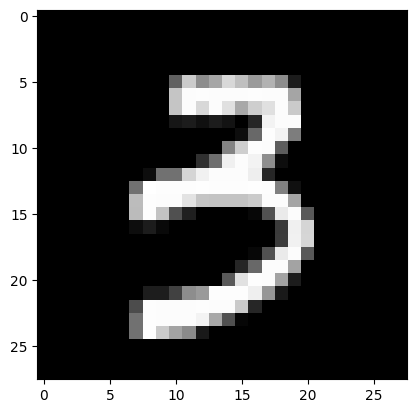

In [ ]:
# test_predictions(index of the row, weights, baises)
test_predictions(7908, W1, b1, W2, b2)

## checking accuracy on dev set

In [65]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
dev_accuracy = get_accuracy(dev_predictions, Y_dev)

[1 0 1 6 0 0 7 3 5 3 8 9 1 3 3 1 8 0 7 6 8 6 2 0 8 3 6 9 9 7 8 9 4 9 6 1 3
 1 1 4 5 1 4 9 2 6 3 7 7 4 7 5 1 9 0 2 2 3 4 1 2 8 9 0 6 3 4 3 1 0 3 4 6 2
 6 4 9 1 4 1 5 4 3 9 2 1 9 8 9 4 5 6 4 6 7 7 1 2 0 3 9 2 7 7 8 8 8 5 0 6 0
 0 2 9 0 4 7 7 1 5 7 9 4 4 1 6 7 6 5 0 4 3 2 8 1 1 7 3 7 3 1 0 3 4 5 4 0 5
 4 5 3 5 1 0 8 3 7 0 9 6 6 9 5 9 1 9 8 5 9 2 4 8 2 9 5 8 8 8 2 6 9 3 1 0 4
 1 5 9 0 6 2 6 3 0 6 0 0 5 3 2 0 8 6 0 0 9 7 2 7 1 9 3 3 9 8 4 1 5 1 3 8 1
 8 7 1 3 7 6 2 6 3 6 3 2 1 6 2 7 9 2 2 2 7 3 5 8 9 2 0 1 4 8 6 3 7 1 1 1 4
 7 0 2 9 2 0 5 6 0 8 9 6 2 0 0 7 2 0 4 2 0 9 1 6 9 3 0 0 2 0 4 8 4 0 7 2 1
 9 5 2 9 8 5 2 9 7 7 2 9 7 4 9 3 6 1 3 6 3 6 8 8 3 7 0 9 2 7 9 0 5 4 5 8 4
 3 3 1 7 8 9 7 6 2 1 7 0 5 6 0 2 9 0 4 6 6 2 2 9 0 7 7 2 2 6 3 4 8 0 5 9 6
 2 1 9 0 6 0 4 5 4 3 1 5 4 2 9 5 7 3 1 5 4 5 3 7 3 8 6 4 4 6 1 1 9 0 0 5 8
 6 7 4 2 8 0 2 5 4 8 3 0 4 4 3 6 9 1 8 1 5 4 7 4 3 2 0 6 0 9 9 2 9 8 9 6 5
 2 4 4 6 4 8 4 1 7 5 8 9 5 8 9 7 5 8 2 2 7 2 8 9 1 9 3 6 0 2 2 4 1 2 7 2 1
 3 4 9 1 8 0 2 2 3 4 1 3 

In [68]:
print(f"Devvelopment Set Accuracy: {dev_accuracy * 100:.0f}%")

Development Set Accuracy: 86%
